In [1]:
import numpy as np
import networkx as nx
import torch
import networkx as nx
import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import tqdm

import os
import pickle

import wandb
import os

import torch
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm

In [42]:
np.arange(9).reshape(3,3).flatten()

array([0, 1, 2, 3, 4, 5, 6, 7, 8])

In [44]:
def create_hmm(states, observations, transition_matrix, initial_distribution=None):
    """
    Create a Hidden Markov Model.
    
    Parameters:
    -----------
    states : list
        List of hidden states
    observations : list
        List of possible observations/emissions
    transition_matrix : numpy.ndarray
        Matrix of Size (num_observations, num_states, num_states)
    initial_distribution : numpy.ndarray, optional
        Initial state distribution. If None, uniform distribution is used.
    
    Returns:
    --------
    dict
        HMM model parameters
    """
    if initial_distribution is None:
        initial_distribution = np.ones(len(states)) / len(states)
    
    return {
        'states': states,
        'observations': observations,
        'transition_matrix': transition_matrix,
        'initial_distribution': initial_distribution
    }


def get_stationary_dist(combined_transition_matrix: np.ndarray) -> np.ndarray:
    merged_transition_matrix = np.sum(combined_transition_matrix, axis=0)

    eigenvalues, eigenvectors = np.linalg.eig(merged_transition_matrix.T)
    fiddler_vec = eigenvectors[:, np.isclose(eigenvalues, 1)].real
    normalized_fiddler_vec = fiddler_vec / fiddler_vec.sum()
    out: np.ndarray = normalized_fiddler_vec[:, 0]
    return out


def get_new_observation(transition_matrix: np.ndarray, currect_state: int) -> int:
    p = transition_matrix[:, currect_state, :].sum(axis=1)
    observation = np.random.choice(transition_matrix.shape[0], p=p)
    return observation


def get_new_state_and_observation(
    transition_matrix: np.ndarray, current_state_idx: int
) -> tuple[int, int]:
    transition_probs = transition_matrix[:, current_state_idx, :]
    state_observation_pair = np.random.choice(transition_probs.size, p=transition_probs.ravel())
    observation_idx = state_observation_pair // transition_matrix.shape[1]
    next_state_idx = state_observation_pair % transition_matrix.shape[1]
    return observation_idx, next_state_idx


def run_hmm(hmm, steps, current_state_idx=None):
    """
    Run a Hidden Markov Model for a given number of steps.
    
    Parameters:
    -----------
    hmm : dict
        HMM model parameters
    steps : int
        Number of steps to run
    
    Returns:
    --------
    tuple
        (state_sequence, observations_sequence)
    """
    states = hmm['states']
    observations = hmm['observations']
    transition_matrix = hmm['transition_matrix']
    initial_distribution = hmm['initial_distribution']
    
    # Sample initial state
    if current_state_idx is None:
        current_state_idx = np.random.choice(len(states), p=initial_distribution)
    
    state_sequence = [states[current_state_idx]]
    observation_sequence = []
    
    for _ in range(steps):
        # Sample observation based on current state
        observation_idx, current_state_idx = get_new_state_and_observation(transition_matrix, current_state_idx)
        
        observation_sequence.append(observations[observation_idx])
        state_sequence.append(states[current_state_idx])
    
    return state_sequence, observation_sequence


def parametrize_hmm3(alpha, x):
    # Define a simple HMM with 3 hidden states and 3 possible observations
    states = ["S1", "S2", "S3"]
    observations = [0, 1, 2]

    # The HMMs in this class are parameterized by α and x, with dependent quantities β = (1 − α)/2 and y = 1 − 2x.
    beta = (1 - alpha) / 2
    y = 1 - 2*x

    # emit 0 and trasition to next state
    T_0 = np.array([
    [alpha*y, beta*x, beta*x],  
    [alpha*x, beta*y, beta*x],  
    [alpha*x, beta*x, beta*y]   
    ])

    # emit 1 and trasition to next state
    T_1 = np.array([
        [beta*y, alpha*x, beta*x],
        [beta*x, alpha*y, beta*x],
        [beta*x, alpha*x, beta*y] 
    ])

    # emit 2 and trasition to next state
    T_2 = np.array([
        [beta*y, beta*x, alpha*x],
        [beta*x, beta*y, alpha*x],
        [beta*x, beta*x, alpha*y] 
    ])

    # Use the emission-specific transition matrices
    combined_transition_matrix = np.array([T_0, T_1, T_2]) 

    stationary_dist = get_stationary_dist(combined_transition_matrix)
    hmm_model = create_hmm(states, observations, combined_transition_matrix, stationary_dist)
    return hmm_model, combined_transition_matrix



 # Define triangle vertices for 0, 1, 2
VERTICIES = {
    "0": np.array([0.0, 1.0]),
    "1": np.array([-np.sqrt(3)/2, -0.5]),
    "2": np.array([np.sqrt(3)/2, -0.5])
}


def hmm_model_to_graph(hmm_model):
    # Create a directed graph from the HMM model
    G = nx.MultiDiGraph()

    # Add nodes (states)
    for state in hmm_model['states']:
        G.add_node(state)

    # Add edges with emission probabilities
    transition_matrix = hmm_model['transition_matrix']
    states = hmm_model['states']
    observations = hmm_model['observations']

    # For each observation, state pair, and next state
    for obs_idx, obs in enumerate(observations):
        for from_state_idx, from_state in enumerate(states):
            for to_state_idx, to_state in enumerate(states):
                # Get probability of emitting obs and transitioning from from_state to to_state
                prob = transition_matrix[obs_idx, from_state_idx, to_state_idx]
                if prob > 0:
                    G.add_edge(
                        from_state,
                        to_state,
                        label=str(obs),
                        weight=prob
                    )
    return G

In [46]:
# Round the transition matrix values for better readability
rounded_matrix = np.round(mess_skewed['transition_matrix'], 2)
print(rounded_matrix)

array([[[0.455  , 0.02625, 0.02625],
        [0.0975 , 0.1225 , 0.02625],
        [0.0975 , 0.02625, 0.1225 ]],

       [[0.1225 , 0.0975 , 0.02625],
        [0.02625, 0.455  , 0.02625],
        [0.02625, 0.0975 , 0.1225 ]],

       [[0.1225 , 0.02625, 0.0975 ],
        [0.02625, 0.1225 , 0.0975 ],
        [0.02625, 0.02625, 0.455  ]]])

In [ ]:
def get_stationary_dist(combined_transition_matrix: np.ndarray) -> np.ndarray:
    merged_transition_matrix = np.sum(combined_transition_matrix, axis=0)

    eigenvalues, eigenvectors = np.linalg.eig(merged_transition_matrix.T)
    fiddler_vec = eigenvectors[:, np.isclose(eigenvalues, 1)].real
    normalized_fiddler_vec = fiddler_vec / fiddler_vec.sum()
    return normalized_fiddler_vec[:, 0]

In [63]:
merged_transition_matrix = parametrize_hmm3(0.65, 0.3)[1]
T = merged_transition_matrix.sum(axis=0)
T / T.sum(axis=1)
eigenvalues, eigenvectors = np.linalg.eig(T)
fiddler_vec = eigenvectors[:, np.isclose(eigenvalues, 1)].real
normalized_fiddler_vec = fiddler_vec / fiddler_vec.sum()


In [69]:
normalized_fiddler_vec.T.shape

(1, 3)

In [49]:
get_stationary_dist(parametrize_hmm3(0.65, 0.3)[1])

array([0.33333333, 0.33333333, 0.33333333])

In [5]:
alpha=0.25
x=0.15
mess3 = parametrize_hmm3(alpha, x)
state_traces, char_traces = run_hmm(mess3, 1000)

In [ ]:


all_char_traces = []
all_state_traces = []

# Generate trajectories sequentially instead of using multiprocessing
# This avoids the pickle error with functions defined in Jupyter notebooks
num_trajectories_per_state = 1_000_000
steps = 10

# Generate trajectories for each start state
for start_state_idx in [0, 1, 2]:
    for _ in tqdm.tqdm(range(num_trajectories_per_state)):
        state_trace, char_trace = run_hmm(mess3, current_state_idx=start_state_idx, steps=steps)
        all_state_traces.append(state_trace)
        all_char_traces.append(char_trace)

print(f"Generated {len(all_char_traces)} trajectories in total")


100%|██████████| 1000000/1000000 [01:17<00:00, 12860.21it/s]

Generated 3000000 trajectories in total
First trajectory length: 10


In [3]:
# Train a transformer model on the character traces


# Define a simple dataset class for our character traces
class CharTraceDataset(Dataset):
    def __init__(self, char_traces, state_traces, seq_length=20):
        self.data = []
        self.state_traces = []
        self.seq_length = seq_length
        

        # Define vocabulary mapping
        # self.vocab = {'A': 0, 'B': 1, 'C': 2}
        self.vocab = {0: 0, 1: 1, 2: 2}
        self.state_vocab = {'S1':0, 'S2':1, 'S3':2}
        
        # Convert character traces to sequences
        for trace, state_trace in zip(char_traces, state_traces):
            # Convert to list if it's a string
            if isinstance(trace, str):
                trace = list(trace)
                
            # Convert characters to indices using vocab
            indices = [self.vocab[c] for c in trace][:seq_length]
            state_indices = [self.state_vocab[s] for s in state_trace][:seq_length]
            self.data.append(indices)
            self.state_traces.append(state_indices)

    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        # Get the sequence data
        sequence = self.data[idx]
        state_seq = self.state_traces[idx]
        
        input_seq = torch.tensor(sequence[:-1], dtype=torch.long)        
        target_seq = torch.tensor(sequence[1:], dtype=torch.long)
        state_seq = torch.tensor(state_seq[:-1], dtype=torch.long) # current state, not next state
        return input_seq, target_seq, state_seq


# Define a simple transformer model
class SimpleTransformer(nn.Module):
    def __init__(self, vocab_size=3, d_model=48, nhead=2, num_layers=1, max_seq_length=20):
        super(SimpleTransformer, self).__init__()
        from transformers import GPT2Config, GPT2Model
        
        # Configure a GPT2 model with our parameters
        self.config = GPT2Config(
            vocab_size=vocab_size,
            n_embd=d_model,
            n_layer=num_layers,
            n_head=nhead,
            n_positions=max_seq_length
        )
        
        # Initialize the GPT2 model
        self.transformer = GPT2Model(self.config)
        
        self.fc_out = nn.Linear(d_model, vocab_size)
        
    def forward(self, x):
        # x shape: [seq_len, batch_size]
        output = self.transformer(x)
        output = self.fc_out(output.last_hidden_state)
        return output

In [15]:
# Create dataset and dataloader
dataset = CharTraceDataset(all_char_traces, all_state_traces)
dataloader = DataLoader(dataset, batch_size=200, shuffle=True)


In [16]:
# Save dataset to file


# Create datasets directory if it doesn't exist
os.makedirs("experiments/datasets", exist_ok=True)

# Create filename based on parameters
filename = f"chaos_game_dataset_alpha_{alpha}_x_{x}.pkl"
filepath = os.path.join("experiments/datasets", filename)

# Save the dataset
with open(filepath, 'wb') as f:
    pickle.dump({
        'char_traces': all_char_traces,
        'state_traces': all_state_traces
    }, f)

print(f"Dataset saved to {filepath}")

Dataset saved to experiments/datasets/chaos_game_dataset_alpha_0.25_x_0.15.pkl


In [6]:
# # Load the dataset from file
import pickle
import os

# Use the same filename as saved above
filename = f"chaos_game_dataset_alpha_{alpha}_x_{x}.pkl"
filepath = os.path.join("experiments/datasets", filename)

# Load the dataset
with open(filepath, 'rb') as f:
    loaded_data = pickle.load(f)
    loaded_char_traces = loaded_data['char_traces']
    loaded_state_traces = loaded_data['state_traces']

print(f"Dataset loaded from {filepath}")
print(f"Number of character traces: {len(loaded_char_traces)}")
print(f"Number of state traces: {len(loaded_state_traces)}")

# Create dataset and dataloader from loaded data
loaded_dataset = CharTraceDataset(loaded_char_traces, loaded_state_traces)
dataloader = DataLoader(loaded_dataset, batch_size=100, shuffle=True)

Dataset loaded from experiments/datasets/chaos_game_dataset_alpha_0.25_x_0.15.pkl
Number of character traces: 3000000
Number of state traces: 3000000


In [36]:
# Initialize the model
device = "mps" # torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = SimpleTransformer(vocab_size=3, d_model=64, nhead=4, num_layers=2, max_seq_length=10).to(device)

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.0005, weight_decay=0.0)

In [71]:
from typing import Dict, Any, Optional, Tuple
def get_belief_history(
    hmm_model: Dict[str, Any],
    observation_sequence: list[int], # Assuming observations are integers 0, 1, ...
    prior_dist: Optional[np.ndarray] = None
) -> Tuple[np.ndarray, list[int]]:
    """
    Returns Trajectory of Belief State Updates. 
    Should be equivalent to the paper formulation at eq. A5. 

    Args:
        hmm_model: Dictionary containing HMM parameters:
            'states': List of state names/identifiers.
            'observations': List of possible observation values (e.g., [0, 1, 2]).
            'transition_matrix': np.ndarray of shape (vocab_len, num_states, num_states)
                        combined, where T[o, s, s'] = P(S_{t+1}=s', O_{t+1}=o | S_t=s).
        observation_sequence: List of observations (as integers matching indices in hmm_model['observations']).
        prior_dist: Initial belief state distribution over states (numpy array).
                    If None, uses the steady-state distribution if available in hmm_model,
                    otherwise defaults to uniform.

    Returns:
        np.array of projected 2D points representing the belief state trajectory.
        The original observation sequence.
    """
    states = hmm_model['states']
    num_states = len(states)
    transition_matrix = hmm_model['transition_matrix'] # T[o, s, s'] 

    # Initialize belief state (prior distribution)
    if prior_dist is not None:
        belief_state = np.array(prior_dist, dtype=float)
    elif 'steady_state' in hmm_model: # Check if steady state is precomputed
        belief_state = np.array(hmm_model['steady_state'], dtype=float)
    else:
        # Use uniform distribution if no prior or steady state provided
        belief_state = np.ones(num_states, dtype=float) / num_states

    belief_history = [belief_state] # Store the history of belief states
    
    # obs should be an integer index corresponding to the observation
    for obs in observation_sequence:
        # equivalent to: beta_t = belief_state @ T[obs, :, :]
        unnormalized_belief = np.einsum("s,sd->d", belief_state, transition_matrix[obs])

        # Normalize belief state
        total = np.sum(unnormalized_belief)
        belief_state = unnormalized_belief / total
       
        belief_history.append(belief_state)

    return  belief_history


def _print_rounded_mat(mat_or_list, up_to=3):
    print(np.round(mat_or_list, up_to))

In [ ]:
# Initialize wandb for experiment tracking
import wandb
import os

# Create experiments directory if it doesn't exist
os.makedirs("experiments/checkpoints", exist_ok=True)

wandb.init(project="belief-state-geometry", name="chaos-game-transformer")


# we will check KL divergence against optimal superposition of beliefs at some points

from torch import Functional as F

def ensure_tensor(p, q):
    p = torch.tensor(p, dtype=torch.float32)
    q = torch.tensor(q, dtype=torch.float32)
    return p, q

def _normalize(p):
    return p / p.sum()

def kl_divergence(p, q):
    p, q = ensure_tensor(p, q)
    p, q = _normalize(p), _normalize(q)
    return F.kl_div(q.log(), p, reduction="sum").item()


import torch.nn.functional as F


def compute_kl_divergence_callback(output, data_batch, hmm_transition_matrices):
    # Get model predictions (distributions over next character)
    with torch.no_grad():
        pred_distributions = F.softmax(output.view(-1, 3), dim=1).cpu().numpy()
    
    # Get optimal distributions from HMM model
    batch_trajectories = data_batch.cpu().numpy()
    optimal_distributions = []
    
    for trajectory in batch_trajectories:
        # Get belief history for this trajectory
        belief_history = get_belief_history(trajectory)
        # Get the last belief state
        last_belief = belief_history[-1]
        
        # Compute weighted sum of transition matrices
        weighted_transition = np.zeros((3, 3))
        for i in range(3):
            weighted_transition += last_belief[i] * hmm_transition_matrices[i]
        
        # Get distribution over next character from weighted transition
        optimal_dist = np.sum(weighted_transition, axis=1)
        optimal_distributions.append(optimal_dist)
    
    optimal_distributions = np.array(optimal_distributions)
    
    # Compute average KL divergence
    kl_divs = []
    for pred, opt in zip(pred_distributions, optimal_distributions):
        kl_divs.append(kl_divergence(pred, opt))
    
    avg_kl_div = np.mean(kl_divs)

# Training loop
num_epochs = 5
for epoch in range(num_epochs):
    model.train()
    total_loss = 0
    
    for batch_idx, (data, target, _) in enumerate(dataloader):
        data, target = data.to(device), target.to(device)
        
        optimizer.zero_grad()
        output = model(data)
        
        # Reshape for loss calculation
        loss = criterion(output.view(-1, 3), target.reshape(-1))
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        
        # Log batch metrics to wandb
        wandb.log({"batch_loss": loss.item(), "batch": batch_idx + epoch * len(dataloader)})
        
        # Only print batch progress every 100 batches and on 10th epochs
        if batch_idx % 1000 == 0:
            # Compute KL divergence between predicted and optimal distributions
            if batch_idx % 1000 == 0 and data.size(0) > 0:
                # Compute KL divergence and log it separately
                kl_div = compute_kl_divergence_callback(output, data, hmm_model)
                # Log KL divergence as a separate metric track
                wandb.log({
                    "kl_divergence": kl_div,
                    "batch": batch_idx + epoch * len(dataloader)
                })
            print(f'Epoch: {epoch+1}, Batch: {batch_idx}, Loss: {loss.item():.4f}')
    
    avg_loss = total_loss / len(dataloader)
    
    # Print progress periodically during the single large epoch
    if batch_idx % 2000 == 0:
        print(f'Progress: {batch_idx}/{len(dataloader)} batches, Average Loss: {avg_loss:.4f}')
    # Log metrics to wandb with batch granularity instead of epoch
    wandb.log({"progress_percentage": (batch_idx / len(dataloader)) * 100, "running_avg_loss": avg_loss})
    
    # Track total tokens processed
    tokens_processed = (epoch + 1) * len(dataloader) * dataloader.batch_size * 10
    
    # Save checkpoint every 1 million tokens
    if tokens_processed % 1000000 < dataloader.batch_size * 10:
        checkpoint_path = f"experiments/checkpoints/transformer_chaos_game_tokens_{tokens_processed}.pt"
        torch.save({
            'epoch': epoch + 1,
            'tokens_processed': tokens_processed,
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'loss': avg_loss,
        }, checkpoint_path)
        wandb.save(checkpoint_path)  # Also save to wandb
        print(f"Checkpoint saved at {tokens_processed} tokens")

print("Training complete!")

# Save the final model
torch.save(model.state_dict(), 'transformer_chaos_game.pt')
wandb.save('transformer_chaos_game.pt')  # Also save to wandb

# Finish the wandb run
wandb.finish()


Failed to detect the name of this notebook, you can set it manually with the WANDB_NOTEBOOK_NAME environment variable to enable code saving.
wandb: Currently logged in as: culpritgene. Use `wandb login --relogin` to force relogin


Epoch: 1, Batch: 0, Loss: 1.1939
Epoch: 1, Batch: 1000, Loss: 1.1119
Epoch: 1, Batch: 2000, Loss: 1.1078
Epoch: 1, Batch: 3000, Loss: 1.1051
Epoch: 1, Batch: 4000, Loss: 1.0998
Epoch: 1, Batch: 5000, Loss: 1.1015
Epoch: 1, Batch: 6000, Loss: 1.0992
Epoch: 1, Batch: 7000, Loss: 1.1020
Epoch: 1, Batch: 8000, Loss: 1.1000
Epoch: 1, Batch: 9000, Loss: 1.0999
Epoch: 1, Batch: 10000, Loss: 1.1020
Epoch: 1, Batch: 11000, Loss: 1.1018
Epoch: 1, Batch: 12000, Loss: 1.0993
Epoch: 1, Batch: 13000, Loss: 1.0988
Epoch: 1, Batch: 14000, Loss: 1.1017
Epoch: 1, Batch: 15000, Loss: 1.1004
Epoch: 1, Batch: 16000, Loss: 1.0993
Epoch: 1, Batch: 17000, Loss: 1.0989
Epoch: 1, Batch: 18000, Loss: 1.0996
Epoch: 1, Batch: 19000, Loss: 1.0971
Epoch: 1, Batch: 20000, Loss: 1.0981
Epoch: 1, Batch: 21000, Loss: 1.0992
Epoch: 1, Batch: 22000, Loss: 1.0978
Epoch: 1, Batch: 23000, Loss: 1.1014
Epoch: 1, Batch: 24000, Loss: 1.0972
Epoch: 1, Batch: 25000, Loss: 1.0991
Epoch: 1, Batch: 26000, Loss: 1.0983
Epoch: 1, Batc

wandb: WARNING Source type is set to 'repo' but some required information is missing from the environment. A job will not be created from this run. See https://docs.wandb.ai/guides/launch/create-job


batch,▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
batch_loss,█▃▄▁▃▃▃▃▃▂▂▃▄▃▃▃▃▃▂▃▁▃▃▂▂▃▃▂▂▂▃▂▂▂▃▂▂▃▂▂
progress_percentage,▁▁▁▁▁
running_avg_loss,█▂▁▁▁
batch,149999
batch_loss,1.09792
progress_percentage,99.99667
running_avg_loss,1.09867


In [34]:
# # Load the trained model
# model2 = SimpleTransformer(vocab_size=3, d_model=64, nhead=2, num_layers=1, max_seq_length=20).to(device)
# model2.load_state_dict(torch.load('/Users/solar/Code/DL/Mechanistic_Interpretability/GeoMechInterp/experiments/experiments/checkpoints/transformer_chaos_game_tokens_30000000.pt'))
# model2.eval()

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(kl_trace)
plt.title('KL Divergence over training trajectory\nComparing model output with optimal character distribution, Batch Average, every 1000 Batches')
plt.xlabel('Batch (x1000)')
plt.ylabel('KL Divergence')
plt.grid(True, alpha=0.3)

In [ ]:
# Collect activations from the trained model



# Load the trained model
# model.load_state_dict(torch.load('/Users/solar/Code/DL/Mechanistic_Interpretability/GeoMechInterp/experiments/experiments/checkpoints/transformer_chaos_game_epoch_250.pt'))
# model.eval()

# model.to(device='mps')
# Specify which layer to extract activations from (e.g., layer 3)
target_layer = 0
# Create a hook to capture activations
activations = []
batched_states = []

# Create a smaller dataset by sampling 1/10 of the data
sample_ratio = 0.1  # Sample 10% of the data

# Create a sampler for the existing dataset
total_samples = len(dataset)
num_samples = int(total_samples * sample_ratio)
indices = torch.randperm(total_samples)[:num_samples]
sampler = torch.utils.data.SubsetRandomSampler(indices)

# Create a new dataloader with the sampler
small_dataloader = DataLoader(
    dataset,
    batch_size=dataloader.batch_size,
    sampler=sampler,
    num_workers=dataloader.num_workers,
    pin_memory=dataloader.pin_memory,
    drop_last=dataloader.drop_last
)

print(f"Created smaller dataloader with {num_samples} samples (original: {total_samples})")

# Use the smaller dataloader for activation collection
dataloader = small_dataloader


# batched_positions = [] 

def hook_fn(module, input, output):
    # Capture the residual stream (input to the layer)
    # print(output[0].shape)
    activations.append(output[0].detach())

# Register the hook to the specified transformer layer
hook = model.transformer.h[target_layer].register_forward_hook(hook_fn)

# Collect activations for the entire dataset
total = 0
with torch.no_grad():
    for i, (data_batch, target, state) in tqdm(enumerate(dataloader), desc="Collecting activations"):
        data_batch = data_batch.to(device)
        target = target.to(device)
        # print(data.shape)
        # # Reshape for transformer: [seq_len, batch_size]
        # data = data.transpose(0, 1)
        # target = target.transpose(0, 1)
        total += data_batch.shape[0]
        # Forward pass
        model(data_batch)
        
        # --- Efficiently store batch labels (still on device) ---
        seq_len, batch_size = data_batch.shape # Assuming data is [seq_len, batch_size] after potential transpose
                                            # If data is [batch_size, seq_len], swap indices below
        
        if state is not None:
                batched_states.append(state.reshape(-1))

# Remove the hook
hook.remove()

In [9]:
# --- Consolidate and move to CPU ---
print(f"Processing {len(activations)} activation tensors...")

# Concatenate all activations and move to CPU
all_activations = torch.cat([t.cpu().reshape(-1, t.shape[-1]) for t in activations], dim=0)
del activations  # Free memory

# Process states if available
if batched_states:
    labels_state_tensor = torch.cat([st.cpu() for st in batched_states], dim=0)
    labels_state = labels_state_tensor.numpy()
    del labels_state_tensor, batched_states
else:
    labels_state = None

print(f"Collected {all_activations.shape[0]} activation vectors of dimension {all_activations.shape[1]}")

# Convert to numpy
activations_np = all_activations.numpy()
del all_activations  # Free memory


Processing 30000 activation tensors...
Collected 27000000 activation vectors of dimension 64


In [57]:
from collections import Counter
flat_data = torch.Tensor(dataset.data).flatten()
for i in [0,1,2]:
    print((flat_data == i).sum())

tensor(499398)
tensor(500864)
tensor(499738)


In [10]:
def map_onto_simplex(points: np.ndarray):
    """Project points onto the 2-simplex (triangle)."""
    x = points[:, 1] + 0.5 * points[:, 2]
    y = (np.sqrt(3) / 2) * points[:, 2]
    return x, y

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# Apply PCA to reduce to 3 dimensions
pca = PCA(n_components=3, whiten=True)
activations_2d = pca.fit_transform(activations_np)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# Convert to simplex coordinates (triangular form)
# For a 3D simplex, we need to project onto a 2D plane
# Using the standard projection of a 3D simplex onto a 2D plane
simplex_vertices = np.array([
    [0, 0],              # Vertex 1
    [1, 0],              # Vertex 2
    [0.5, np.sqrt(3)/2]  # Vertex 3
])


# Normalize PCA components to sum to 1 (for simplex projection)
row_sums = np.abs(activations_2d).sum(axis=1)
normalized_activations = np.abs(activations_2d) / row_sums[:, np.newaxis]

# Project onto 2D simplex
simplex_coords = normalized_activations @ simplex_vertices

Explained variance ratio: [0.24797503 0.11964327 0.10318099]


In [22]:
x,y = map_onto_simplex(activations_2d)

In [ ]:

pca = PCA(n_components=2)
activations_2d = pca.fit_transform(activations_np)
print(f"Explained variance ratio: {pca.explained_variance_ratio_}")

# Plot activations colored by position in sequence
plt.figure(figsize=(12, 10))
plt.subplot(1, 2, 1)
scatter = plt.scatter(activations_2d[:, 0], activations_2d[:, 1], c=labels_position, cmap='viridis', alpha=0.5, s=5)
plt.colorbar(scatter, label='Position in sequence')
plt.title(f'PCA of Layer {target_layer} Activations (by Position)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

# Plot activations colored by target
plt.subplot(1, 2, 2)
scatter = plt.scatter(activations_2d[:, 0], activations_2d[:, 1], c=labels_target, cmap='tab10', alpha=0.5, s=5)
plt.colorbar(scatter, label='Target')
plt.title(f'PCA of Layer {target_layer} Activations (by Target)')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%})')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%})')

plt.tight_layout()
plt.savefig(f'layer_{target_layer}_activations_pca.png')
plt.show()

# # Log to wandb
# wandb.init(project="belief-state-geometry", name=f"activations-pca-layer-{target_layer}")
# wandb.log({"activations_pca": wandb.Image(plt)})
# wandb.finish()


In [3]:

def simulate_fsm_chaos_uniform(G, start_state, steps):
    current_state = start_state
    point = np.array([0.0, 0.0])
    points = []

    char_traces = []
    state_traces = []

    for _ in range(steps):
        # Get all outgoing edges from current state
        edges = list(G.out_edges(current_state, data=True))
        
        # Extract edge data
        next_states = [edge[1] for edge in edges]
        weights = [edge[2]['weight'] for edge in edges]
        labels = [edge[2]['label'] for edge in edges]
        
        # Normalize weights if needed
        total_weight = sum(weights)
        if total_weight > 0:
            normalized_weights = [w / total_weight for w in weights]
        else:
            normalized_weights = [1.0 / len(weights)] * len(weights)
        
        # Sample an edge based on weights
        edge_idx = random.choices(range(len(edges)), weights=normalized_weights, k=1)[0]
        
        # Get the next state and emitted symbol
        next_state = next_states[edge_idx]
        emitted_symbol = labels[edge_idx]
        
        # Chaos game move
        vertex = VERTICIES[emitted_symbol]
        point = (point + vertex) / 2
        points.append(point)
        
        # Update state
        current_state = next_state
        
        char_traces.append(emitted_symbol)
        state_traces.append(current_state)

    return np.array(points), char_traces, state_traces


def simulate_belief_state_chaos(hmm_model, observation_sequence, prior_dist=None):
    """
    Simulates the chaos game based on belief states rather than actual states.
    
    Args:
        hmm_model: Dictionary containing HMM parameters
        observation_sequence: List of observations (as strings)
        prior_dist: Initial distribution over states (if None, use uniform)
    
    Returns:
        np.array of points, observation sequence
    """
    states = hmm_model['states']
    observations = hmm_model['observations']
    transition_matrix = hmm_model['transition_matrix']
    
    # Initialize belief state (prior distribution)
    if prior_dist is None:
        # Use uniform distribution if not provided
        belief_state = np.ones(len(states)) / len(states)
    else:
        belief_state = np.array(prior_dist)
    
    points = []
    
    for obs in observation_sequence:
        # Convert observation to index
        obs_idx = observations.index(int(obs)) if isinstance(obs, str) else observations.index(obs)
        
        # Update belief state based on observation
        new_belief = np.zeros(len(states))
        
        for to_state_idx in range(len(states)):
            for from_state_idx in range(len(states)):
                # P(next_state | current_state, observation)
                prob = transition_matrix[obs_idx, from_state_idx, to_state_idx]
                new_belief[to_state_idx] += belief_state[from_state_idx] * prob
        
        # Normalize belief state
        total = np.sum(new_belief)
        if total > 0:
            belief_state = new_belief / total
        
        # Project belief state directly onto the triangle
        # For a 3-state system, we can directly use the belief state as barycentric coordinates
        # This assumes states are ordered to match the vertices
        point = np.zeros(2)
        for i, state_prob in enumerate(belief_state):
            point += state_prob * VERTICIES[str(i)]
        
        points.append(point)
    
    return np.array(points), observation_sequence

In [30]:
import numpy as np
from typing import List, Optional, Dict, Any, Tuple

# Define the projection vertices (example for a standard equilateral triangle)
# You should replace this with the specific vertices you need, matching the repo's TRIANGLE_PROJECTION if necessary
VERTICES = {
    '0': np.array([0.0, 0.0]),             # Vertex for state 0
    '1': np.array([1.0, 0.0]),             # Vertex for state 1
    '2': np.array([0.5, np.sqrt(3)/2])     # Vertex for state 2
}
# Make sure the order matches your states/belief vector indices

def get_belief_history(
    hmm_model: Dict[str, Any],
    observation_sequence: List[int], # Assuming observations are integers 0, 1, ...
    prior_dist: Optional[np.ndarray] = None
) -> Tuple[np.ndarray, List[int]]:
    """
    Calculates the sequence of belief states for a single observation sequence.

    Args:
        hmm_model: Dictionary containing HMM parameters:
            'states': List of state names/identifiers.
            'observations': List of possible observation values (e.g., [0, 1, 2]).
            'transition_matrix': np.ndarray of shape (vocab_len, num_states, num_states)
                                 where T[o, s, s'] = P(S_{t+1}=s', O_{t+1}=o | S_t=s).
        observation_sequence: List of observations (as integers matching indices in hmm_model['observations']).
        prior_dist: Initial belief state distribution over states (numpy array).
                    If None, uses the steady-state distribution if available in hmm_model,
                    otherwise defaults to uniform.

    Returns:
        np.array of projected 2D points representing the belief state trajectory.
        The original observation sequence.
    """
    states = hmm_model['states']
    num_states = len(states)
    transition_matrix = hmm_model['transition_matrix'] # T[o, s, s'] 

    # Initialize belief state (prior distribution)
    if prior_dist is not None:
        belief_state = np.array(prior_dist, dtype=float)
    elif 'steady_state' in hmm_model: # Check if steady state is precomputed
        belief_state = np.array(hmm_model['steady_state'], dtype=float)
    else:
        # Use uniform distribution if no prior or steady state provided
        belief_state = np.ones(num_states, dtype=float) / num_states

    belief_history = [belief_state] # Store the history of belief states

    for obs in observation_sequence:
        # obs should be an integer index corresponding to the observation

        # equivalent to: beta_t = belief_state @ T[obs, :, :]
        unnormalized_belief = np.einsum("s,sd->d", belief_state, transition_matrix[obs])

        # Normalize belief state
        total = np.sum(unnormalized_belief)
        belief_state = unnormalized_belief / total
       
        belief_history.append(belief_state)

    return  belief_history

In [33]:
mess3['transition_matrix']

array([[[0.175  , 0.05625, 0.05625],
        [0.0375 , 0.2625 , 0.05625],
        [0.0375 , 0.05625, 0.2625 ]],

       [[0.2625 , 0.0375 , 0.05625],
        [0.05625, 0.175  , 0.05625],
        [0.05625, 0.0375 , 0.2625 ]],

       [[0.2625 , 0.05625, 0.0375 ],
        [0.05625, 0.2625 , 0.0375 ],
        [0.05625, 0.05625, 0.175  ]]])

In [32]:
# sanity check

get_belief_history(mess3, [0,0,0,0,0,0,0,0,0])

[array([0.33333333, 0.33333333, 0.33333333]),
 array([0.25 , 0.375, 0.375]),
 array([0.21198157, 0.39400922, 0.39400922]),
 array([0.19506027, 0.40246986, 0.40246986]),
 array([0.18761189, 0.40619405, 0.40619405]),
 array([0.18434928, 0.40782536, 0.40782536]),
 array([0.18292322, 0.40853839, 0.40853839]),
 array([0.18230049, 0.40884976, 0.40884976]),
 array([0.18202866, 0.40898567, 0.40898567]),
 array([0.18191003, 0.40904498, 0.40904498])]

In [5]:
import numpy as np
from typing import List, Set, Tuple, Dict, Any
from collections import deque

def get_all_belief_states_for_fractal(
    hmm_model: Dict[str, Any],
    max_depth: int,
    initial_belief_state: np.ndarray
) -> Set[Tuple[float, ...]]:
    """
    Computes all unique belief states reachable within max_depth.

    Args:
        hmm_model: Dictionary with 'transition_matrix' (shape: vocab, states, states),
                   'observations' (list of possible observations, e.g., [0, 1, 2]).
        max_depth: Maximum length of observation sequences to consider.
        initial_belief_state: The starting belief state (e.g., steady state).

    Returns:
        A set of unique belief states (represented as tuples for hashing).
    """
    transition_matrix = hmm_model['transition_matrix']
    observations = hmm_model['observations']
    vocab_len = len(observations)
    num_states = transition_matrix.shape[1]

    # Use a set to store unique belief states encountered (as tuples)
    # Start with the initial belief state
    all_belief_states = {tuple(initial_belief_state)}

    # Use a queue for breadth-first exploration: (current_belief, current_depth)
    queue = deque([(initial_belief_state, 0)])
    visited_depths = {tuple(initial_belief_state): 0} # Track depth to avoid redundant computation if cycles exist

    while queue:
        current_belief, current_depth = queue.popleft()

        if current_depth >= max_depth:
            continue

        # For each possible next observation
        for obs_idx in range(vocab_len):
            # Calculate the unnormalized next belief state (same logic as before)
            unnormalized_next_belief = np.einsum("s,sd->d", current_belief, transition_matrix[obs_idx])
            norm = np.sum(unnormalized_next_belief)

            if norm > 1e-9: # Check if the observation is possible from the current belief
                next_belief = unnormalized_next_belief / norm
                next_belief_tuple = tuple(next_belief)

                # Check if we've seen this state before at this depth or earlier
                # Or simply add all states if cycles aren't a major concern for plotting
                if next_belief_tuple not in visited_depths or visited_depths[next_belief_tuple] > current_depth + 1:
                     all_belief_states.add(next_belief_tuple)
                     visited_depths[next_belief_tuple] = current_depth + 1
                     queue.append((next_belief, current_depth + 1))
            # else: observation obs_idx is impossible from current_belief, prune this branch

    return all_belief_states

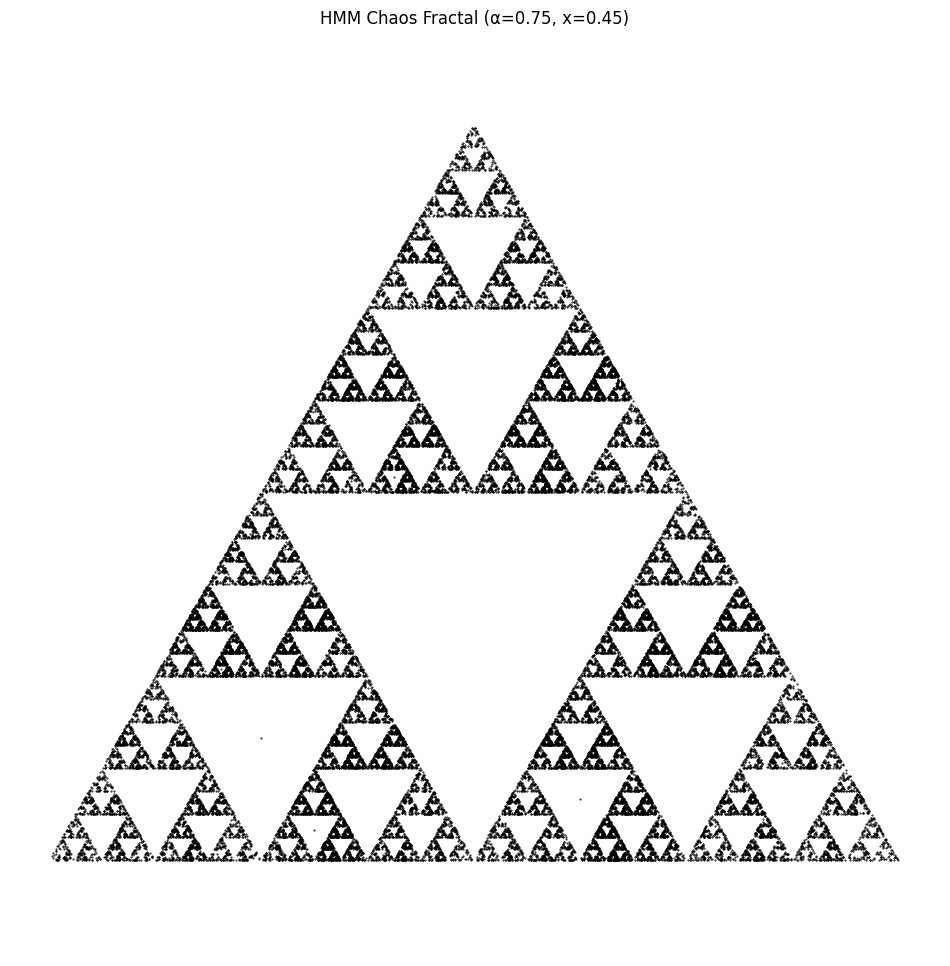

In [7]:
alpha = 0.75
x = 0.45

mess3 = parametrize_hmm3(alpha, x)
G = hmm_model_to_graph(mess3)
points, char_traces, state_traces = simulate_fsm_chaos_uniform(G, start_state="S1", steps=50000)

# state_sequence, observation_sequence = run_hmm(mess3, 50000)
# points, observation_sequence = simulate_belief_state_chaos(mess3, observation_sequence, prior_dist=get_stationary_dist(mess3['transition_matrix']))
all_belief_states = get_all_belief_states_for_fractal(mess3, 10, initial_belief_state=get_stationary_dist(mess3['transition_matrix']))
plt.figure(figsize=(12, 12))
plt.scatter(points[:, 0], points[:, 1], s=0.2, color='black')
plt.axis('equal')
plt.axis('off')
plt.title("HMM Chaos Fractal (α={}, x={})".format(alpha, x))
plt.show()

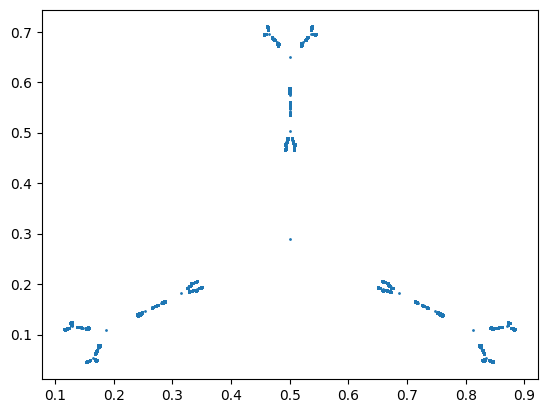

In [13]:

# 1. Get the initial belief state (e.g., steady state)
#    If using Mess3 class: initial_belief = Mess3(x=0.15, a=0.6).steady_state_vector
#    Otherwise, ensure it's in your hmm_model or calculate it.
# initial_belief = hmm_model['steady_state']

# 2. Compute all reachable belief states up to a depth (e.g., 9 or higher for good fractal)
# fractal_depth = 9
# all_states_tuples = get_all_belief_states_for_fractal(hmm_model, fractal_depth, initial_belief)

# 3. Convert tuples back to numpy arrays for projection
all_states_np = np.array(list(all_belief_states)) # Shape: (num_unique_states, num_hmm_states)

# 4. Project onto 2D simplex (using the repo's projection matrix is recommended)
projected_points = map_onto_simplex(all_states_np) # Check dimensions match

# 5. Plot the projected_points
# import matplotlib.pyplot as plt
plt.scatter(projected_points[0], projected_points[1], s=1) # Adjust size 's' as needed
# Add triangle boundaries, labels etc. similar to plot_ground_truth_simplex
plt.show()

In [12]:
projected_points[0]

array([0.82689976, 0.23959289, 0.45595596, ..., 0.28531537, 0.17114745,
       0.46342442])

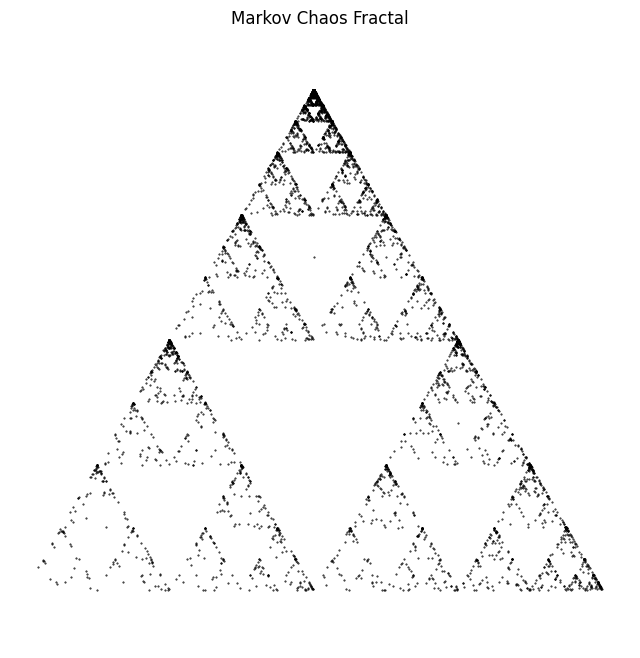

In [39]:

# Each node is a state, each edge has {symbol: prob} for emissions
# Format: G.add_edge(from, to, emissions={"A": 0.03, "B": 0.04, "C": 0.03})
G = nx.DiGraph()
G.add_edge("S1", "S1", emissions={"A": 0.77, "B": 0.07, "C": 0.07})
G.add_edge("S1", "S2", emissions={"A": 0.03, "B": 0.04, "C": 0.03})
G.add_edge("S1", "S3", emissions={"A": 0.04, "B": 0.03, "C": 0.03})

G.add_edge("S2", "S2", emissions={"A": 0.33, "B": 0.33, "C": 0.33})
G.add_edge("S2", "S1", emissions={"A": 0.4, "B": 0.1, "C": 0.16})
G.add_edge("S2", "S3", emissions={"A": 0.03, "B": 0.03, "C": 0.04})

G.add_edge("S3", "S3", emissions={"A": 0.07, "B": 0.07, "C": 0.33})
G.add_edge("S3", "S1", emissions={"A": 0.04, "B": 0.03, "C": 0.03})
G.add_edge("S3", "S2", emissions={"A": 0.03, "B": 0.03, "C": 0.04})

# 2. Define triangle vertices for A, B, C
vertices = {
    "A": np.array([0.0, 1.0]),
    "B": np.array([-np.sqrt(3)/2, -0.5]),
    "C": np.array([np.sqrt(3)/2, -0.5])
}
def simulate_fsm_chaos_uniform(G, start_state, steps):
    current_state = start_state
    point = np.array([0.0, 0.0])
    points = []

    char_traces = []
    state_traces = []

    for _ in range(steps):
        # First: compute transition probabilities (by summing emission weights)
        transition_options = []
        transition_weights = []
        for succ in G.successors(current_state):
            emissions = G[current_state][succ]['emissions']
            total_prob = sum(emissions.values())
            if total_prob > 0:
                transition_options.append(succ)
                transition_weights.append(total_prob)

        # Normalize transition probabilities
        transition_probs = [w / sum(transition_weights) for w in transition_weights]

        # Sample next state
        next_state = random.choices(transition_options, weights=transition_probs, k=1)[0]

        # Then: sample emission symbol given the transition
        emission_dict = G[current_state][next_state]['emissions']
        symbols = list(emission_dict.keys())
        symbol_weights = list(emission_dict.values())

        # Normalize emission probabilities on that edge
        emission_probs = [w / sum(symbol_weights) for w in symbol_weights]

        emitted_symbol = random.choices(symbols, weights=emission_probs, k=1)[0]

        # Chaos game move
        vertex = vertices[emitted_symbol]
        point = (point + vertex) / 2
        points.append(point)

        # Update state
        current_state = next_state

        char_traces.append(emitted_symbol)
        state_traces.append(current_state)

    return np.array(points), char_traces, state_traces

# 4. Run and plot
points, char_traces, state_traces = simulate_fsm_chaos_uniform(G, start_state="S2", steps=5000)

plt.figure(figsize=(8, 8))
plt.scatter(points[:, 0], points[:, 1], s=0.2, color='black')
plt.axis('equal')
plt.axis('off')
plt.title("Markov Chaos Fractal")
plt.show()

In [ ]:

class HMM:
    def __init__(self, states, observations, emission_matrices, steady_state_vector=None):
        """
        Initialize HMM with emission-specific transition matrices.
        
        Args:
            states: List of state names
            observations: List of possible observations
            emission_matrices: List of transition matrices, one per observation
            steady_state_vector: Initial state distribution (optional)
        """
        self.states = states
        self.observations = observations
        self.num_states = len(states)
        self.vocab_len = len(observations)
        
        # Store emission-specific transition matrices in shape (vocab_len, state, state)
        self.transition_matrix = np.stack(emission_matrices, axis=0)
        
        # Calculate steady state vector if not provided
        if steady_state_vector is None:
            # Compute average transition matrix
            avg_transition = np.mean(self.transition_matrix, axis=0)
            # Find steady state by eigendecomposition
            eigenvalues, eigenvectors = np.linalg.eig(avg_transition.T)
            # Find the eigenvector corresponding to eigenvalue 1
            idx = np.argmin(np.abs(eigenvalues - 1.0))
            steady_state = np.real(eigenvectors[:, idx])
            self.steady_state_vector = steady_state / steady_state.sum()
        else:
            self.steady_state_vector = steady_state_vector
    
    def _sample_emission(self, current_state_idx: int | None = None) -> int:
        if current_state_idx is None:
            current_state_idx = np.random.choice(
                self.num_states, p=self.steady_state_vector
            )

        assert (
            0 <= current_state_idx < self.num_states
        ), "current_state_index must be positive & less than num_states"

        p = self.transition_matrix[:, current_state_idx, :].sum(axis=1)
        emission = np.random.choice(self.vocab_len, p=p)
        return emission

    def yield_emissions(
        self, sequence_len: int, current_state_idx: int | None = None
    ) -> Iterator[int]:
        if current_state_idx is None:
            current_state_idx = np.random.choice(
                self.num_states, p=self.steady_state_vector
            )
        assert (
            0 <= current_state_idx < self.num_states
        ), "current_state_index must be positive & less than num_states"
        for _ in range(sequence_len):
            emission, next_state_idx = self._sample_emission_and_next_state(
                current_state_idx
            )
            yield emission
            current_state_idx = next_state_idx

    def _sample_emission_and_next_state(
        self, current_state_idx: int
    ) -> tuple[int, int]:
        transition_probs = self.transition_matrix[:, current_state_idx, :] # (vocab_len, state)
        emission_next_state_idx = np.random.choice(
            transition_probs.size, p=transition_probs.ravel()
        )
        emission = emission_next_state_idx // self.num_states
        next_state_idx = emission_next_state_idx % self.num_states
        return emission, next_state_idx
    
    def generate_sequence(self, steps, start_state=None):
        """Generate a sequence of observations and states"""
        if start_state is None:
            current_state_idx = np.random.choice(self.num_states, p=self.steady_state_vector)
        else:
            current_state_idx = self.states.index(start_state)
            
        state_sequence = [self.states[current_state_idx]]
        observation_sequence = []
        
        for _ in range(steps):
            emission, next_state_idx = self._sample_emission_and_next_state(current_state_idx)
            observation_sequence.append(self.observations[emission])
            current_state_idx = next_state_idx
            state_sequence.append(self.states[current_state_idx])
            
        return self.states[current_state_idx], observation_sequence, state_sequence

def create_hmm(states, observations, emission_matrices, steady_state_vector=None):
    """
    Create an HMM from emission-specific transition matrices.
    
    Args:
        states: List of state names
        observations: List of possible observations
        emission_matrices: List of transition matrices, one per observation
        steady_state_vector: Initial state distribution (optional)
    """
    return HMM(states, observations, emission_matrices, steady_state_vector)